# Practical 1: Variational Autoencoder (VAE)

Implementation of a Variational Autoencoder using the MNIST dataset.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Load MNIST dataset

In [ ]:
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten 28x28 images into 784-dimensional vectors

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (60000, 784)
Testing data shape: (10000, 784)


### Display sample images

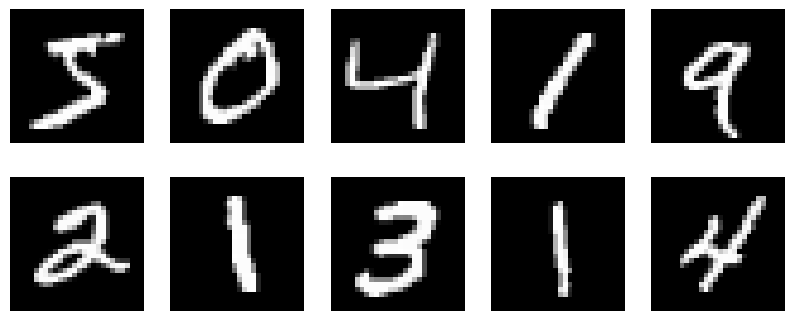

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.show()

In [5]:
latent_dim = 16

class Sampling(layers.Layer):
    def call(self, inputs):
        #mean and variance
        z_mean, z_log_var = inputs  

        epsilon = tf.random.normal(
            shape=tf.shape(z_mean)
        )
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# Encoder

In [6]:
encoder_inputs = layers.Input(shape=(784,))

x = layers.Dense(256, activation="relu")(encoder_inputs)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    200,960 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 16)        │      4,112 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 16)        │      4,112 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 209,184 (817.12 KB)

 Trainable params: 209,184 (817.12 KB)

 Non-trainable params: 0 (0.00 B)

# Decoder

In [ ]:
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(256, activation="relu")(latent_inputs)

decoder_outputs = layers.Dense(784, activation="sigmoid")(x)
 
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,840 (804.06 KB)

 Trainable params: 205,840 (804.06 KB)

 Non-trainable params: 0 (0.00 B)

# VAE model

In [ ]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

        # self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        # self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        # self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction


    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]  # considering only x_train and x_test in (x_train,y_train)&(x_test,xy_train)

        with tf.GradientTape() as tape:
            z_mean, z_log_var = self.encoder(data)

            epsilon = tf.random.normal(shape=tf.shape(z_mean))
            z = z_mean + tf.exp(0.5 * z_log_var) * epsilon

            reconstruction = self.decoder(z)

            # Reconstruction Loss
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(
                        data, reconstruction
                    ),
                    axis=-1
                )
            )

            #kl divergence Loss
            kl_loss = -0.5 * tf.reduce_mean(
                    tf.reduce_sum(
                        1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                        axis=1
                    )
            )

            #Total loss
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)

        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # self.total_loss_tracker.update_state(total_loss)
        # self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        # self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss":kl_loss,
        }

# Compile and train the VAE

In [ ]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())

# Do not pass validation_data here because the custom VAE class
# implements train_step() but does not implement call()/test_step().
history = vae.fit(
    x_train,
    epochs=10,
    batch_size=128,
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 3.2428 - loss: 23.8781 - reconstruction_loss: 20.6353
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 4.0344 - loss: 23.0072 - reconstruction_loss: 18.9728
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 4.6904 - loss: 23.3577 - reconstruction_loss: 18.6673
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 4.7073 - loss: 21.7631 - reconstruction_loss: 17.0558
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.0074 - loss: 21.6575 - reconstruction_loss: 16.6501
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.5512 - loss: 22.6309 - reconstruction_loss: 17.0797
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 5.3085 - loss: 21.6592 - reconstruction_loss: 16.3507
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 5.7018 - loss: 21.8410 - reconstruction_loss: 16.1392
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 5

# Reconstruct Test Images

In [21]:
z_mean, z_log_var = encoder.predict(
    x_test[:10]
)

epsilon = tf.random.normal(shape=tf.shape(z_mean))
z = z_mean + tf.exp(0.5 * z_log_var) * epsilon

reconstructed = decoder.predict(z)

reconstructed.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


(10, 784)

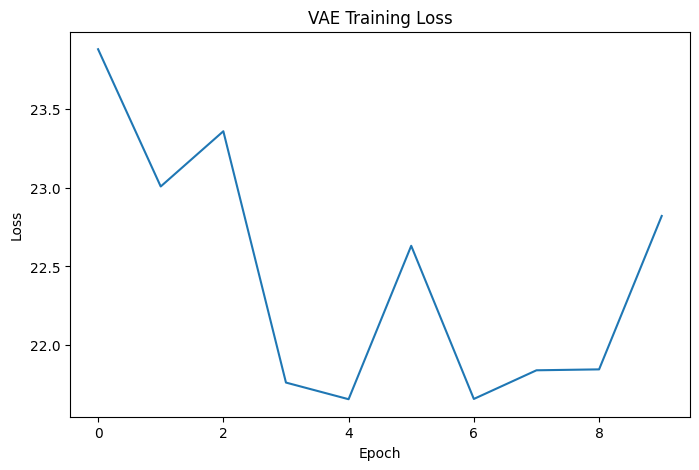

In [22]:
# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")
plt.show()

# Reconstruct test images

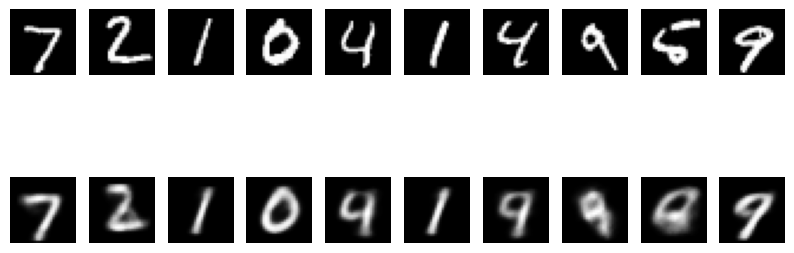

In [ ]:
z_mean_test, z_log_var_test = encoder.predict(x_test, verbose=0)
reconstructed = decoder.predict(z_mean_test, verbose=0)

plt.figure(figsize=(10, 4))
for i in range(10):

    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Reconstruction
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.show()

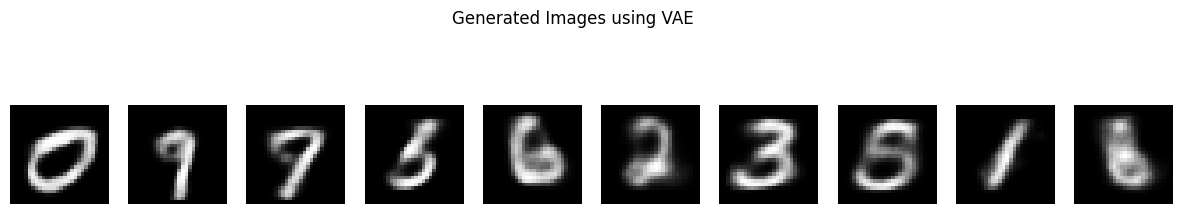

In [24]:
# Generate new images from random points in latent space
n = 10
random_latent_vectors = np.random.normal(size=(n, latent_dim))
generated_images = decoder.predict(random_latent_vectors, verbose=0)

plt.figure(figsize=(15, 3))
for i in range(n):
    plt.subplot(1, n, i + 1)
    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.suptitle("Generated Images using VAE")
plt.show()